# NHS Waiting Time Analysis

## Project Objective
This project analyses NHS waiting time data to identify trends, regional variations, and operational bottlenecks in healthcare services.

## Tools Used
Python (Pandas, NumPy)
Data Visualisation (Matplotlib, Seaborn)
Excel Dataset

## Key Skills Demonstrated
Data Cleaning
Exploratory Data Analysis
Trend Analysis
Data Visualisation
Healthcare Data Insights

## 1.Import Libraries

In [ ]:
import pandas as pd

# Load the data from your file
df = pd.read_excel(r'C:\new\nhs_wait.xlsx',sheet_name='Type 1 Time Series')

# Display the first few rows to confirm it loaded correctly
print(df.head())

   Unnamed: 0 Unnamed: 1                                         Unnamed: 2  \
0         NaN     Title:               A&E Activity and Performance Summary   
1         NaN   Summary:  Type 1 & 2 ECDS Attendances (Total & Admitted)...   
2         NaN        NaN                                                NaN   
3         NaN    Period:                              February 2023 onwards   
4         NaN    Source:                                 ECDS - NHS England   

  Unnamed: 3 Unnamed: 4 Unnamed: 5 Unnamed: 6 Unnamed: 7  
0        NaN        NaN        NaN        NaN        NaN  
1        NaN        NaN        NaN        NaN        NaN  
2        NaN        NaN        NaN        NaN        NaN  
3        NaN        NaN        NaN        NaN        NaN  
4        NaN        NaN        NaN        NaN        NaN  


In [19]:
# Check the number of missing values in each column
print(df.isnull().sum())

Unnamed: 0    50
Unnamed: 1     5
Unnamed: 2    42
Unnamed: 3    20
Unnamed: 4    20
Unnamed: 5    20
Unnamed: 6    20
Unnamed: 7    20
dtype: int64


## 2. Load Dataset

In [35]:
# Assuming your headers are on the 15th row (index 14)
df = pd.read_excel(r'C:\new\nhs_wait.xlsx',sheet_name='Type 1 Time Series', header=14)

In [37]:
print(df.head())

   Unnamed: 0               Period  Unnamed: 2  Total Attendances  \
0         NaN  2023-02-01 00:00:00         NaN          1241285.0   
1         NaN  2023-03-01 00:00:00         NaN          1407215.0   
2         NaN  2023-04-01 00:00:00         NaN          1268335.0   
3         NaN  2023-05-01 00:00:00         NaN          1386750.0   
4         NaN  2023-06-01 00:00:00         NaN          1354540.0   

   Admitted Attendances  A&E Attendances >12hrs from arrival  \
0              286240.0                             128580.0   
1              318425.0                             146920.0   
2              295100.0                              99930.0   
3              310810.0                             113140.0   
4              303775.0                             104020.0   

   A&E Attendances 12hr % Denominator  12hr %  
0                           1241285.0   0.104  
1                           1407215.0   0.104  
2                           1268335.0   0.079  
3       

In [39]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 36 entries, 0 to 35
Data columns (total 8 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   Unnamed: 0                           0 non-null      float64
 1   Period                               34 non-null     object 
 2   Unnamed: 2                           0 non-null      float64
 3   Total Attendances                    29 non-null     float64
 4   Admitted Attendances                 29 non-null     float64
 5   A&E Attendances >12hrs from arrival  29 non-null     float64
 6   A&E Attendances 12hr % Denominator   29 non-null     float64
 7   12hr %                               29 non-null     float64
dtypes: float64(7), object(1)
memory usage: 2.4+ KB
None


## 3. Data Cleaning

In [45]:
# Permanently drop the specified columns from the DataFrame
df = df.drop(['Unnamed: 0', 'Unnamed: 2'], axis=1)

In [47]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 36 entries, 0 to 35
Data columns (total 6 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   Period                               34 non-null     object 
 1   Total Attendances                    29 non-null     float64
 2   Admitted Attendances                 29 non-null     float64
 3   A&E Attendances >12hrs from arrival  29 non-null     float64
 4   A&E Attendances 12hr % Denominator   29 non-null     float64
 5   12hr %                               29 non-null     float64
dtypes: float64(5), object(1)
memory usage: 1.8+ KB
None


## 4.Data Preparation

In [53]:
# Convert the 'Period' column to datetime, forcing any errors to NaT
df['Period'] = pd.to_datetime(df['Period'], errors='coerce')

In [55]:
# Check for any remaining NaT values
print(df['Period'].isnull().sum())

7


In [57]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 36 entries, 0 to 35
Data columns (total 6 columns):
 #   Column                               Non-Null Count  Dtype         
---  ------                               --------------  -----         
 0   Period                               29 non-null     datetime64[ns]
 1   Total Attendances                    29 non-null     float64       
 2   Admitted Attendances                 29 non-null     float64       
 3   A&E Attendances >12hrs from arrival  29 non-null     float64       
 4   A&E Attendances 12hr % Denominator   29 non-null     float64       
 5   12hr %                               29 non-null     float64       
dtypes: datetime64[ns](1), float64(5)
memory usage: 1.8 KB
None


In [59]:
# Drop rows where the 'Period' column has a missing value (NaT)
df = df.dropna(subset=['Period'])

In [61]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
Index: 29 entries, 0 to 28
Data columns (total 6 columns):
 #   Column                               Non-Null Count  Dtype         
---  ------                               --------------  -----         
 0   Period                               29 non-null     datetime64[ns]
 1   Total Attendances                    29 non-null     float64       
 2   Admitted Attendances                 29 non-null     float64       
 3   A&E Attendances >12hrs from arrival  29 non-null     float64       
 4   A&E Attendances 12hr % Denominator   29 non-null     float64       
 5   12hr %                               29 non-null     float64       
dtypes: datetime64[ns](1), float64(5)
memory usage: 1.6 KB
None


In [63]:
# Get a statistical summary of the numerical columns
print(df.describe())

                              Period  Total Attendances  Admitted Attendances  \
count                             29       2.900000e+01             29.000000   
mean   2024-03-31 23:10:20.689655296       1.383852e+06         330928.172414   
min              2023-02-01 00:00:00       1.202520e+06         271100.000000   
25%              2023-09-01 00:00:00       1.345265e+06         310810.000000   
50%              2024-04-01 00:00:00       1.379834e+06         337536.000000   
75%              2024-11-01 00:00:00       1.453043e+06         349675.000000   
max              2025-06-01 00:00:00       1.486107e+06         378535.000000   
std                              NaN       7.305035e+04          27405.980729   

       A&E Attendances >12hrs from arrival  \
count                            29.000000   
mean                         138210.241379   
min                           96260.000000   
25%                          124615.000000   
50%                          143603.0000

In [63]:
# Get a statistical summary of the numerical columns
print(df.describe())

                              Period  Total Attendances  Admitted Attendances  \
count                             29       2.900000e+01             29.000000   
mean   2024-03-31 23:10:20.689655296       1.383852e+06         330928.172414   
min              2023-02-01 00:00:00       1.202520e+06         271100.000000   
25%              2023-09-01 00:00:00       1.345265e+06         310810.000000   
50%              2024-04-01 00:00:00       1.379834e+06         337536.000000   
75%              2024-11-01 00:00:00       1.453043e+06         349675.000000   
max              2025-06-01 00:00:00       1.486107e+06         378535.000000   
std                              NaN       7.305035e+04          27405.980729   

       A&E Attendances >12hrs from arrival  \
count                            29.000000   
mean                         138210.241379   
min                           96260.000000   
25%                          124615.000000   
50%                          143603.0000

In [67]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [73]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
Index: 29 entries, 0 to 28
Data columns (total 6 columns):
 #   Column                               Non-Null Count  Dtype         
---  ------                               --------------  -----         
 0   Period                               29 non-null     datetime64[ns]
 1   Total Attendances                    29 non-null     float64       
 2   Admitted Attendances                 29 non-null     float64       
 3   A&E Attendances >12hrs from arrival  29 non-null     float64       
 4   A&E Attendances 12hr % Denominator   29 non-null     float64       
 5   12hr %                               29 non-null     float64       
dtypes: datetime64[ns](1), float64(5)
memory usage: 1.6 KB
None


In [ ]:
utc_df = pd.read_excel(r,'C:\new\nhs_wait.xlsx',sheet_name='UTC Time Series')

In [75]:
df.rename(columns={
    'Total Attendances': 'Total_Attendances',
    'Admitted Attendances': 'Admitted_Attendances',
    'A&E Attendances >12hrs from arrival': 'Wait_12hr_plus',
    'A&E Attendances 12hr % Denominator': 'Wait_12hr_denominator',
    '12hr %': 'Percent_Wait_12hr_plus'})

,Period,Total_Attendances,Admitted_Attendances,Wait_12hr_plus,Wait_12hr_denominator,Percent_Wait_12hr_plus
0,2023-02-01,1241285.0,286240.0,128580.0,1241285.0,0.104000
1,2023-03-01,1407215.0,318425.0,146920.0,1407215.0,0.104000
2,2023-04-01,1268335.0,295100.0,99930.0,1268335.0,0.079000
3,2023-05-01,1386750.0,310810.0,113140.0,1386750.0,0.082000
4,2023-06-01,1354540.0,303775.0,104020.0,1354540.0,0.077000
5,2023-07-01,1345265.0,299440.0,96260.0,1345265.0,0.072000
6,2023-08-01,1202520.0,271100.0,99905.0,1202520.0,0.083000
7,2023-09-01,1341480.0,293420.0,124615.0,1341480.0,0.093000
8,2023-10-01,1358465.0,310475.0,146525.0,1358465.0,0.108000
9,2023-11-01,1356785.0,317325.0,147030.0,1356785.0,0.108000


In [79]:
utc_df = pd.read_excel(r'C:\new\nhs_wait.xlsx',sheet_name='UTC Time Series')

In [81]:
print(utc_df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 43 entries, 0 to 42
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  0 non-null      float64
 1   Unnamed: 1  38 non-null     object 
 2   Unnamed: 2  8 non-null      object 
 3   Unnamed: 3  23 non-null     object 
 4   Unnamed: 4  23 non-null     object 
dtypes: float64(1), object(4)
memory usage: 1.8+ KB
None


In [83]:
# Drop columns and rows that are entirely NaN
utc_df = utc_df.dropna(axis=1, how='all')
utc_df = utc_df.dropna(axis=0, how='all')

In [85]:
print(utc_df.info())

<class 'pandas.core.frame.DataFrame'>
Index: 38 entries, 0 to 42
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Unnamed: 1  38 non-null     object
 1   Unnamed: 2  8 non-null      object
 2   Unnamed: 3  23 non-null     object
 3   Unnamed: 4  23 non-null     object
dtypes: object(4)
memory usage: 1.5+ KB
None


In [87]:
# Convert 'Period' to datetime, coercing errors, then drop NaT rows
utc_df['Period'] = pd.to_datetime(utc_df['Period'], errors='coerce')

KeyError: 'Period'

In [89]:
utc_df = utc_df.dropna(subset=['Period']).set_index('Period').sort_index()

KeyError: ['Period']

In [93]:
# Rename columns for clarity
utc_df.rename(columns={
    'Total Attendances': 'Total_Attendances',
    'Admitted Attendances': 'Admitted_Attendances'})

,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,Title:,A&E Activity and Performance Summary,NaN,NaN
1,Summary:,Urgent Treatment Centres (UTCs) ECDS Attendanc...,NaN,NaN
3,Period:,September 2023 onwards,NaN,NaN
4,Source:,ECDS - NHS England,NaN,NaN
5,Basis:,National,NaN,NaN
6,Published:,10th July 2025,NaN,NaN
7,Revised:,NaN,NaN,NaN
8,Status:,Published - Official Statistics in development,NaN,NaN
9,Contact:,Kerry Evert - england.aedata@nhs.net,NaN,NaN
11,National Level Data,NaN,NaN,NaN


In [95]:
# --- Generate the plot for A&E 12hr wait percentages ---
plt.figure(figsize=(12, 6))

<Figure size 1200x600 with 0 Axes>

<Figure size 1200x600 with 0 Axes>

In [97]:
sns.lineplot(x=df.index, y='Percent_Wait_12hr_plus', data=df)

ValueError: Could not interpret value `Percent_Wait_12hr_plus` for `y`. An entry with this name does not appear in `data`.

In [99]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
Index: 29 entries, 0 to 28
Data columns (total 6 columns):
 #   Column                               Non-Null Count  Dtype         
---  ------                               --------------  -----         
 0   Period                               29 non-null     datetime64[ns]
 1   Total Attendances                    29 non-null     float64       
 2   Admitted Attendances                 29 non-null     float64       
 3   A&E Attendances >12hrs from arrival  29 non-null     float64       
 4   A&E Attendances 12hr % Denominator   29 non-null     float64       
 5   12hr %                               29 non-null     float64       
dtypes: datetime64[ns](1), float64(5)
memory usage: 1.6 KB
None


In [101]:
df.rename(columns={
    'Total Attendances': 'Total_Attendances',
    'Admitted Attendances': 'Admitted_Attendances',
    'A&E Attendances >12hrs from arrival': 'Wait_12hr_plus',
    'A&E Attendances 12hr % Denominator': 'Wait_12hr_denominator',
    '12hr %': 'Percent_Wait_12hr_plus'})

,Period,Total_Attendances,Admitted_Attendances,Wait_12hr_plus,Wait_12hr_denominator,Percent_Wait_12hr_plus
0,2023-02-01,1241285.0,286240.0,128580.0,1241285.0,0.104000
1,2023-03-01,1407215.0,318425.0,146920.0,1407215.0,0.104000
2,2023-04-01,1268335.0,295100.0,99930.0,1268335.0,0.079000
3,2023-05-01,1386750.0,310810.0,113140.0,1386750.0,0.082000
4,2023-06-01,1354540.0,303775.0,104020.0,1354540.0,0.077000
5,2023-07-01,1345265.0,299440.0,96260.0,1345265.0,0.072000
6,2023-08-01,1202520.0,271100.0,99905.0,1202520.0,0.083000
7,2023-09-01,1341480.0,293420.0,124615.0,1341480.0,0.093000
8,2023-10-01,1358465.0,310475.0,146525.0,1358465.0,0.108000
9,2023-11-01,1356785.0,317325.0,147030.0,1356785.0,0.108000


## 5.Exploratory Data Analysis

<Axes: xlabel='None', ylabel='12hr %'>

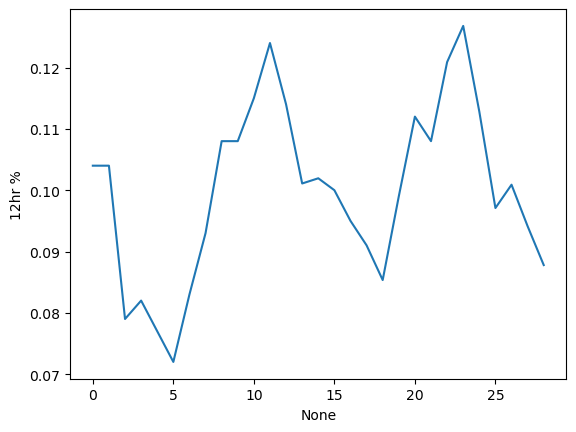

In [105]:
sns.lineplot(x=df.index, y='12hr %', data=df)

Text(0.5, 1.0, 'Percentage of A&E Attendances Waiting >12hrs (Feb 2023 - June 2025)')

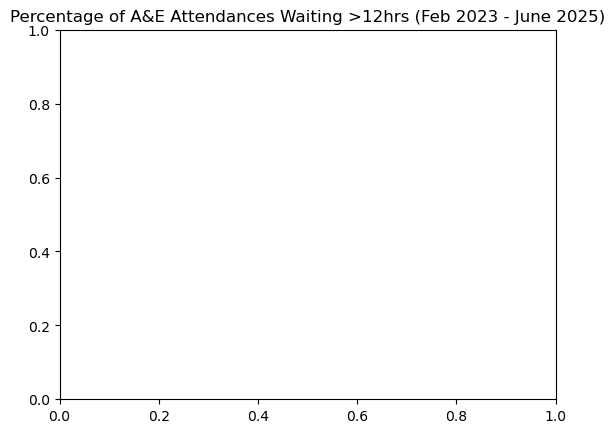

In [107]:
plt.title('Percentage of A&E Attendances Waiting >12hrs (Feb 2023 - June 2025)')

Text(0.5, 0, 'Date')

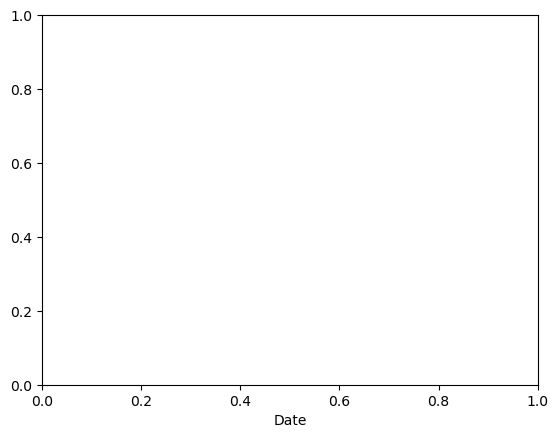

In [109]:
plt.xlabel('Date')

Text(0, 0.5, 'Percentage of Patients (%)')

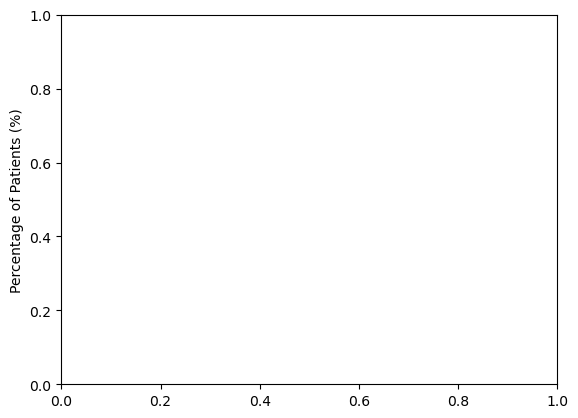

In [111]:
plt.ylabel('Percentage of Patients (%)')

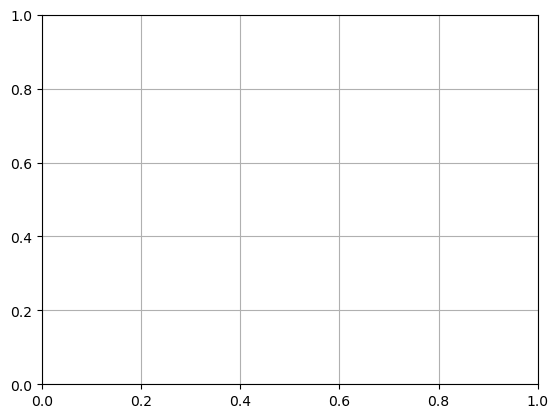

In [113]:
plt.grid(True)

In [115]:
plt.tight_layout()

<Figure size 640x480 with 0 Axes>

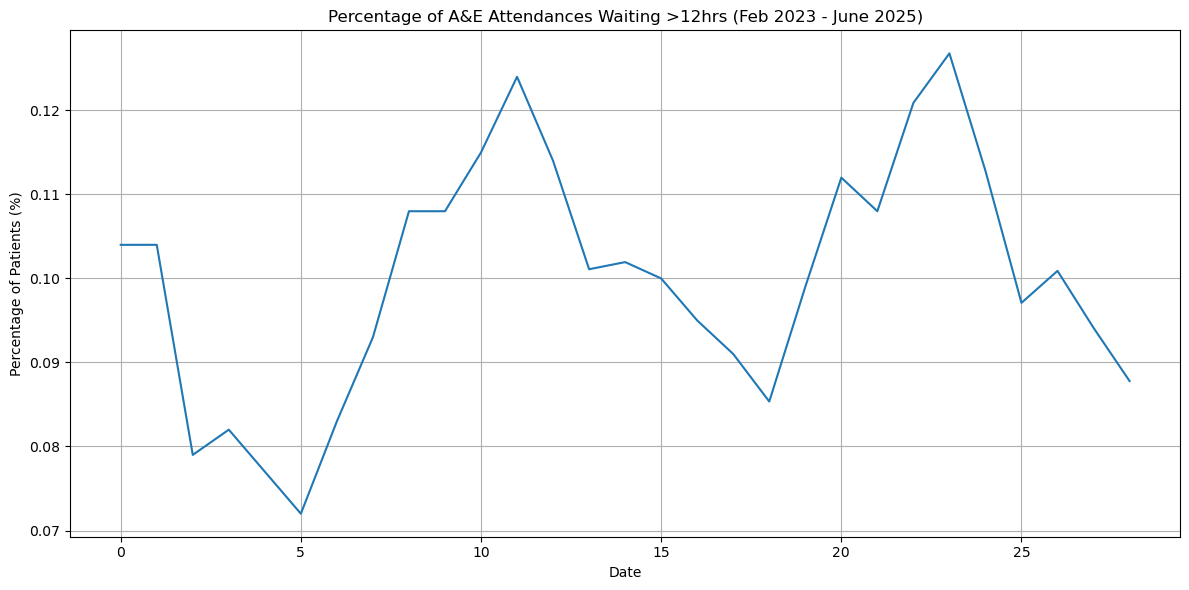

In [121]:
plt.figure(figsize=(12, 6))
sns.lineplot(x=df.index, y='12hr %', data=df)
plt.title('Percentage of A&E Attendances Waiting >12hrs (Feb 2023 - June 2025)')
plt.xlabel('Date')
plt.ylabel('Percentage of Patients (%)')
plt.grid(True)
plt.tight_layout()

In [123]:
df['Period'] = pd.to_datetime(df['Period'], errors='coerce')

In [125]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
Index: 29 entries, 0 to 28
Data columns (total 6 columns):
 #   Column                               Non-Null Count  Dtype         
---  ------                               --------------  -----         
 0   Period                               29 non-null     datetime64[ns]
 1   Total Attendances                    29 non-null     float64       
 2   Admitted Attendances                 29 non-null     float64       
 3   A&E Attendances >12hrs from arrival  29 non-null     float64       
 4   A&E Attendances 12hr % Denominator   29 non-null     float64       
 5   12hr %                               29 non-null     float64       
dtypes: datetime64[ns](1), float64(5)
memory usage: 1.6 KB
None


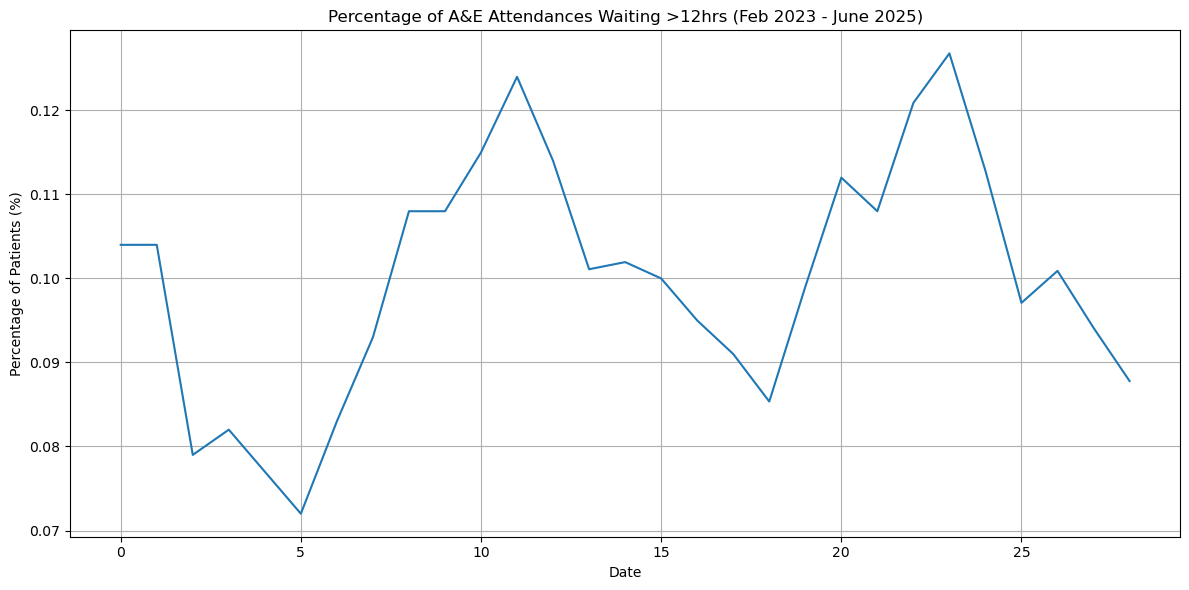

In [127]:
plt.figure(figsize=(12, 6))
sns.lineplot(x=df.index, y='12hr %', data=df)
plt.title('Percentage of A&E Attendances Waiting >12hrs (Feb 2023 - June 2025)')
plt.xlabel('Date')
plt.ylabel('Percentage of Patients (%)')
plt.grid(True)
plt.tight_layout()

In [135]:
# Drop any rows with invalid dates and set the Period column as the index
df = df.dropna(subset=['Period']).set_index('Period')

KeyError: ['Period']

In [145]:
# Load the data from your file
df = pd.read_excel(r'C:\new\nhs_wait.xlsx',sheet_name='Type 1 Time Series',header=14)

In [149]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df['Period'] = pd.to_datetime(df['Period'], errors='coerce')

In [155]:
df.dropna(subset=['Period']).set_index('Period').sort_index()

,Unnamed: 0,Unnamed: 2,Total Attendances,Admitted Attendances,A&E Attendances >12hrs from arrival,A&E Attendances 12hr % Denominator,12hr %
Period,,,,,,,
2023-02-01,NaN,NaN,1241285.0,286240.0,128580.0,1241285.0,0.104000
2023-03-01,NaN,NaN,1407215.0,318425.0,146920.0,1407215.0,0.104000
2023-04-01,NaN,NaN,1268335.0,295100.0,99930.0,1268335.0,0.079000
2023-05-01,NaN,NaN,1386750.0,310810.0,113140.0,1386750.0,0.082000
2023-06-01,NaN,NaN,1354540.0,303775.0,104020.0,1354540.0,0.077000
2023-07-01,NaN,NaN,1345265.0,299440.0,96260.0,1345265.0,0.072000
2023-08-01,NaN,NaN,1202520.0,271100.0,99905.0,1202520.0,0.083000
2023-09-01,NaN,NaN,1341480.0,293420.0,124615.0,1341480.0,0.093000
2023-10-01,NaN,NaN,1358465.0,310475.0,146525.0,1358465.0,0.108000


In [169]:
dc_df = pd.read_excel(r'C:\new\nhs_wait.xlsx',sheet_name='Data Completeness & Quality', header=17)

In [177]:
utc_df = pd.read_excel(r'C:\new\nhs_wait.xlsx',sheet_name='UTC Time Series',header=14)

In [161]:
utc_df = utc_df.dropna(axis=1, how='all')
utc_df = utc_df.dropna(axis=0, how='all')

In [181]:
utc_df['Period'] = pd.to_datetime(utc_df['Period'], errors='coerce')

In [183]:
utc_df = utc_df.dropna(subset=['Period']).set_index('Period').sort_index()

In [179]:
print(utc_df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 29 entries, 0 to 28
Data columns (total 5 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Unnamed: 0            0 non-null      float64
 1   Period                27 non-null     object 
 2   Unnamed: 2            0 non-null      float64
 3   Total Attendances     22 non-null     float64
 4   Admitted Attendances  22 non-null     float64
dtypes: float64(4), object(1)
memory usage: 1.3+ KB
None


In [173]:
# Rename columns for clarity
utc_df = utc_df.rename(columns={
    'Total Attendances': 'Total_Attendances',
    'Admitted Attendances': 'Admitted_Attendances'
})

In [187]:
print(utc_df.info())

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 22 entries, 2023-09-01 to 2025-06-01
Data columns (total 4 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Unnamed: 0            0 non-null      float64
 1   Unnamed: 2            0 non-null      float64
 2   Total Attendances     22 non-null     float64
 3   Admitted Attendances  22 non-null     float64
dtypes: float64(4)
memory usage: 880.0 bytes
None


In [189]:
utc_df = utc_df.dropna(axis=1, how='all')
utc_df = utc_df.dropna(axis=0, how='all')

In [191]:
print(utc_df.info())

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 22 entries, 2023-09-01 to 2025-06-01
Data columns (total 2 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Total Attendances     22 non-null     float64
 1   Admitted Attendances  22 non-null     float64
dtypes: float64(2)
memory usage: 528.0 bytes
None


In [193]:
# --- Calculate admissions rate for A&E and UTCs ---
df['Admissions_Rate'] = (df['Admitted Attendances'] / df['Total Attendances']) * 100
utc_df['Admissions_Rate'] = (utc_df['Admitted Attendances'] / utc_df['Total Attendances']) * 100

In [205]:
# --- Combine the admissions rates for plotting ---
admissions_rates = pd.concat([df['Admissions_Rate'], utc_df['Admissions_Rate']], axis=1)
admissions_rates.columns = ['A&E Admissions Rate', 'UTC Admissions Rate']


In [207]:
admissions_rates.info()

<class 'pandas.core.frame.DataFrame'>
Index: 58 entries, 0 to 2025-06-01 00:00:00
Data columns (total 2 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   A&E Admissions Rate  29 non-null     float64
 1   UTC Admissions Rate  22 non-null     float64
dtypes: float64(2)
memory usage: 1.4+ KB


In [211]:
# Check the data types before plotting
print("--- Admissions Rates DataFrame Info ---")
admissions_rates.info()
print("---------------------------------------")

--- Admissions Rates DataFrame Info ---
<class 'pandas.core.frame.DataFrame'>
Index: 58 entries, 0 to 2025-06-01 00:00:00
Data columns (total 2 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   A&E Admissions Rate  29 non-null     float64
 1   UTC Admissions Rate  22 non-null     float64
dtypes: float64(2)
memory usage: 3.4+ KB
---------------------------------------


In [199]:
# --- Generate the plot for admissions rates ---
plt.figure(figsize=(12, 6))

<Figure size 1200x600 with 0 Axes>

<Figure size 1200x600 with 0 Axes>

TypeError: Invalid object type at position 36

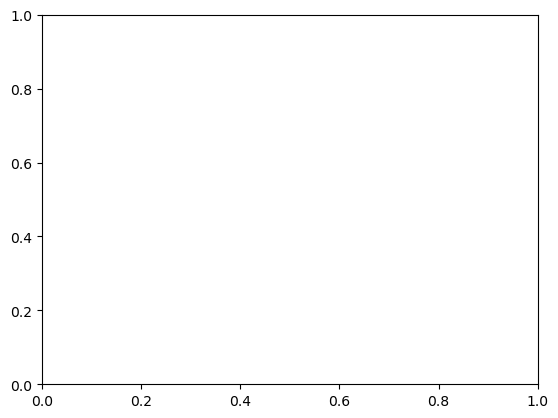

In [209]:
sns.lineplot(data=admissions_rates)

In [213]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [217]:
# Re-load the data from CSV files with the correct header rows.
type1_df = pd.read_excel(r'C:\new\nhs_wait.xlsx',sheet_name='Type 1 Time Series', header=14)
utc_df = pd.read_excel(r'C:\new\nhs_wait.xlsx',sheet_name= 'UTC Time Series', header=14)
completeness_df = pd.read_excel(r'C:\new\nhs_wait.xlsx',sheet_name='Data Completeness & Quality', header=17)

In [219]:
# --- Clean Type 1 Time Series Data ---
type1_df = type1_df.dropna(axis=1, how='all')
type1_df = type1_df.dropna(axis=0, how='all')

In [221]:
print(type1_df.info())

<class 'pandas.core.frame.DataFrame'>
Index: 34 entries, 0 to 35
Data columns (total 6 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   Period                               34 non-null     object 
 1   Total Attendances                    29 non-null     float64
 2   Admitted Attendances                 29 non-null     float64
 3   A&E Attendances >12hrs from arrival  29 non-null     float64
 4   A&E Attendances 12hr % Denominator   29 non-null     float64
 5   12hr %                               29 non-null     float64
dtypes: float64(5), object(1)
memory usage: 1.9+ KB
None


In [223]:
type1_df['Period'] = pd.to_datetime(type1_df['Period'], errors='coerce')

In [225]:
print(type1_df.info())

<class 'pandas.core.frame.DataFrame'>
Index: 34 entries, 0 to 35
Data columns (total 6 columns):
 #   Column                               Non-Null Count  Dtype         
---  ------                               --------------  -----         
 0   Period                               29 non-null     datetime64[ns]
 1   Total Attendances                    29 non-null     float64       
 2   Admitted Attendances                 29 non-null     float64       
 3   A&E Attendances >12hrs from arrival  29 non-null     float64       
 4   A&E Attendances 12hr % Denominator   29 non-null     float64       
 5   12hr %                               29 non-null     float64       
dtypes: datetime64[ns](1), float64(5)
memory usage: 1.9 KB
None


In [227]:
type1_df = type1_df.dropna(subset=['Period']).set_index('Period').sort_index()

In [229]:
print(type1_df.info())

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 29 entries, 2023-02-01 to 2025-06-01
Data columns (total 5 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   Total Attendances                    29 non-null     float64
 1   Admitted Attendances                 29 non-null     float64
 2   A&E Attendances >12hrs from arrival  29 non-null     float64
 3   A&E Attendances 12hr % Denominator   29 non-null     float64
 4   12hr %                               29 non-null     float64
dtypes: float64(5)
memory usage: 1.4 KB
None


In [231]:
type1_df.rename(columns={
    'Total Attendances': 'Total_Attendances',
    'Admitted Attendances': 'Admitted_Attendances',
    'A&E Attendances >12hrs from arrival': 'Wait_12hr_plus',
    'A&E Attendances 12hr % Denominator': 'Wait_12hr_denominator',
    '12hr %': 'Percent_Wait_12hr_plus'
})

,Total_Attendances,Admitted_Attendances,Wait_12hr_plus,Wait_12hr_denominator,Percent_Wait_12hr_plus
Period,,,,,
2023-02-01,1241285.0,286240.0,128580.0,1241285.0,0.104000
2023-03-01,1407215.0,318425.0,146920.0,1407215.0,0.104000
2023-04-01,1268335.0,295100.0,99930.0,1268335.0,0.079000
2023-05-01,1386750.0,310810.0,113140.0,1386750.0,0.082000
2023-06-01,1354540.0,303775.0,104020.0,1354540.0,0.077000
2023-07-01,1345265.0,299440.0,96260.0,1345265.0,0.072000
2023-08-01,1202520.0,271100.0,99905.0,1202520.0,0.083000
2023-09-01,1341480.0,293420.0,124615.0,1341480.0,0.093000
2023-10-01,1358465.0,310475.0,146525.0,1358465.0,0.108000


In [233]:
# --- Clean UTC Time Series Data ---
utc_df = utc_df.dropna(axis=1, how='all')
utc_df = utc_df.dropna(axis=0, how='all')

In [235]:
print(utc_df.info())

<class 'pandas.core.frame.DataFrame'>
Index: 27 entries, 0 to 28
Data columns (total 3 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Period                27 non-null     object 
 1   Total Attendances     22 non-null     float64
 2   Admitted Attendances  22 non-null     float64
dtypes: float64(2), object(1)
memory usage: 864.0+ bytes
None


In [237]:
utc_df['Period'] = pd.to_datetime(utc_df['Period'], errors='coerce')

In [239]:
print(utc_df.info())

<class 'pandas.core.frame.DataFrame'>
Index: 27 entries, 0 to 28
Data columns (total 3 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   Period                22 non-null     datetime64[ns]
 1   Total Attendances     22 non-null     float64       
 2   Admitted Attendances  22 non-null     float64       
dtypes: datetime64[ns](1), float64(2)
memory usage: 864.0 bytes
None


In [241]:
utc_df = utc_df.dropna(subset=['Period']).set_index('Period').sort_index()

In [243]:
print(utc_df.info())

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 22 entries, 2023-09-01 to 2025-06-01
Data columns (total 2 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Total Attendances     22 non-null     float64
 1   Admitted Attendances  22 non-null     float64
dtypes: float64(2)
memory usage: 528.0 bytes
None


In [249]:
utc_df.rename(columns={
    'Total Attendances': 'Total_Attendances',
    'Admitted Attendances': 'Admitted_Attendances'
})

,Total_Attendances,Admitted_Attendances
Period,,
2023-09-01,424900.0,19910.0
2023-10-01,417835.0,21895.0
2023-11-01,412245.0,21280.0
2023-12-01,408975.0,19160.0
2024-01-01,429820.0,17220.0
2024-02-01,420190.0,14420.0
2024-03-01,499960.0,24030.0
2024-04-01,463109.0,23446.0
2024-05-01,429951.0,23580.0


In [257]:
# --- Calculate admissions rate for A&E and UTCs ---
type1_df['Admissions Rate'] = (type1_df['Admitted Attendances'] / type1_df['Total Attendances']) * 100
utc_df['Admissions Rate'] = (utc_df['Admitted Attendances'] / utc_df['Total Attendances']) * 100

In [259]:
# --- Combine the admissions rates for plotting ---
admissions_rates = pd.concat([type1_df['Admissions Rate'], utc_df['Admissions Rate']], axis=1)
admissions_rates.columns = ['A&E Admissions Rate', 'UTC Admissions Rate']

In [261]:
# Check the data types before plotting
print("--- Admissions Rates DataFrame Info ---")
admissions_rates.info()
print("---------------------------------------")

--- Admissions Rates DataFrame Info ---
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 29 entries, 2023-02-01 to 2025-06-01
Freq: MS
Data columns (total 2 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   A&E Admissions Rate  29 non-null     float64
 1   UTC Admissions Rate  22 non-null     float64
dtypes: float64(2)
memory usage: 696.0 bytes
---------------------------------------


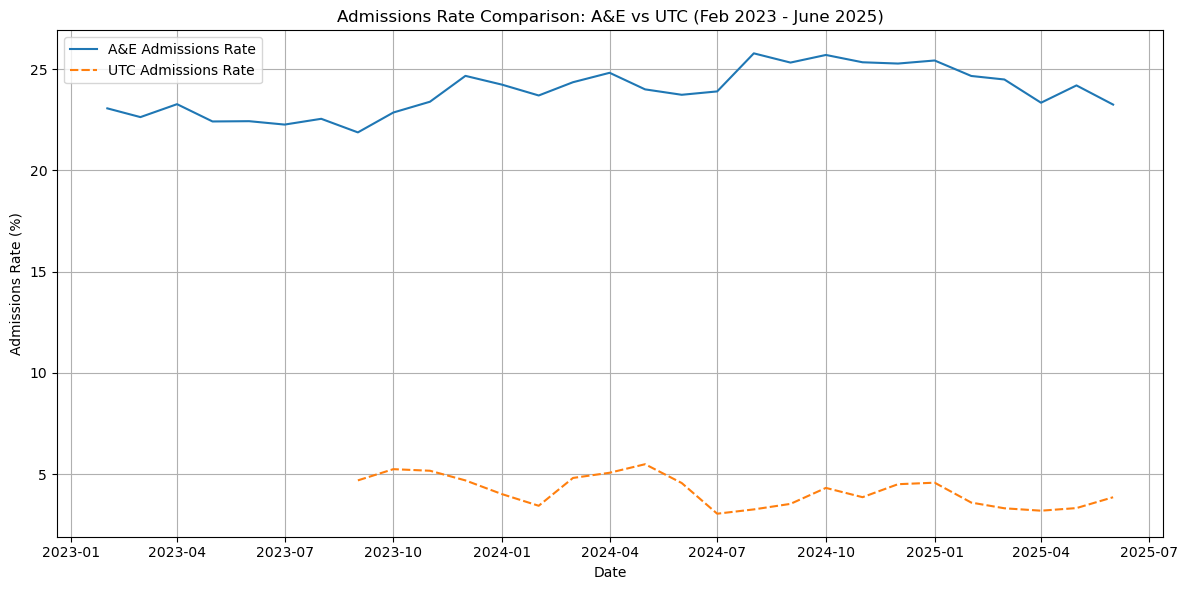

In [263]:
# --- Generate the plot for admissions rates ---
plt.figure(figsize=(12, 6))
sns.lineplot(data=admissions_rates)
plt.title('Admissions Rate Comparison: A&E vs UTC (Feb 2023 - June 2025)')
plt.xlabel('Date')
plt.ylabel('Admissions Rate (%)')
plt.grid(True)
plt.tight_layout()

In [265]:
plt.savefig('admissions_rate_comparison.png')

<Figure size 640x480 with 0 Axes>

In [267]:
print("Plot saved as admissions_rate_comparison.png")

Plot saved as admissions_rate_comparison.png


In [269]:
import os
print(os.getcwd())

C:\Users\hp\Desktop


In [271]:
# --- Clean Data Completeness & Quality Data ---
# Select the relevant columns for Type 1 and UTC providers
type1_completeness = completeness_df[['Period', 'Total Number of Type 1 Providers']].copy()
utc_completeness = completeness_df[['Period.1', 'Total Number of UTC Providers']].copy()

In [273]:
# Drop rows with NaN values and reset index
type1_completeness = type1_completeness.dropna().reset_index(drop=True)
utc_completeness = utc_completeness.dropna().reset_index(drop=True)

In [275]:
# Convert period columns to datetime and set as index
type1_completeness['Period'] = pd.to_datetime(type1_completeness['Period'])
utc_completeness['Period.1'] = pd.to_datetime(utc_completeness['Period.1'])
type1_completeness = type1_completeness.rename(columns={'Period': 'Date'}).set_index('Date')
utc_completeness = utc_completeness.rename(columns={'Period.1': 'Date'}).set_index('Date')


In [277]:
# --- Combine the two completeness dataframes for plotting ---
combined_completeness = pd.concat([
    type1_completeness['Total Number of Type 1 Providers'],
    utc_completeness['Total Number of UTC Providers']
], axis=1)
combined_completeness.columns = ['Type 1 Providers', 'UTC Providers']

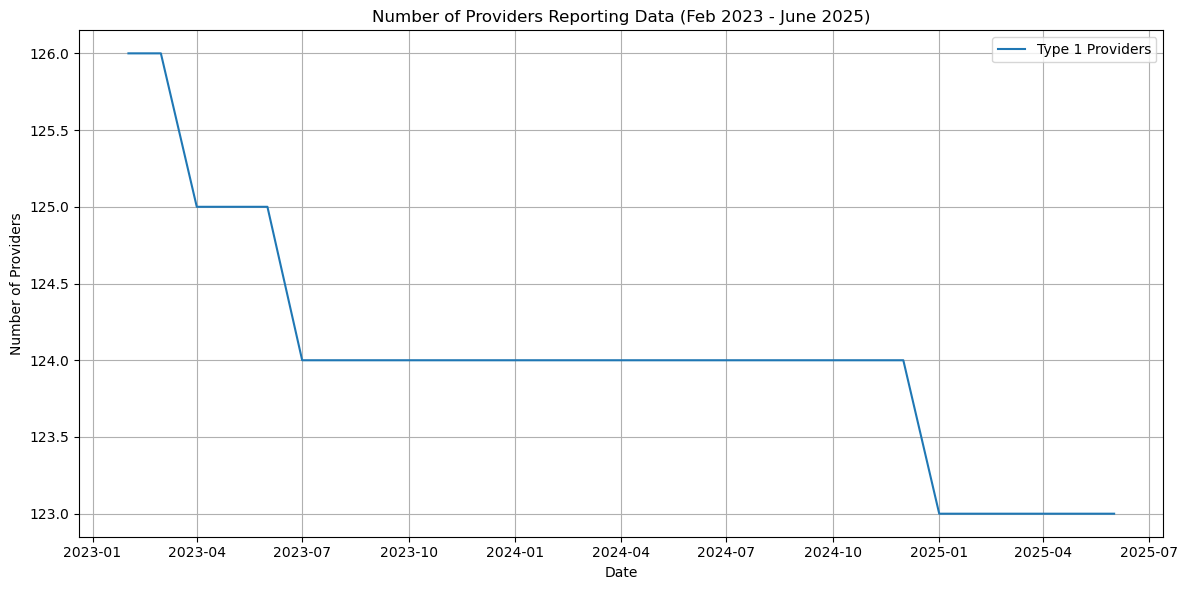

In [279]:
# --- Generate the plot for data completeness ---
plt.figure(figsize=(12, 6))
sns.lineplot(data=combined_completeness)
plt.title('Number of Providers Reporting Data (Feb 2023 - June 2025)')
plt.xlabel('Date')
plt.ylabel('Number of Providers')
plt.grid(True)
plt.tight_layout()

In [281]:
plt.savefig('provider_completeness_trend.png')

print("Plot saved as provider_completeness_trend.png")

Plot saved as provider_completeness_trend.png


<Figure size 640x480 with 0 Axes>

Title
Project Objective

1 Import Libraries
2 Load Dataset
3 Data Cleaning
4 Data Preparation
5 Exploratory Data Analysis
6 Key Insights